# Modeling Human Activity States Using Hidden Markov Models




**Team Members:**
- Jean (iPhone X — Sensor Logger iOS, 100 Hz)
- Thierry (iPhone X — Sensor Logger iOS, 100 Hz)

**Activities Recorded:** Standing · Walking · Jumping · Still

**Sensors Used:** Accelerometer (x, y, z) · Gyroscope (x, y, z)



## Table of Contents
1. [Setup & Dependencies](#1)
2. [Data Loading & Exploration](#2)
3. [Preprocessing & Resampling](#3)
4. [Feature Extraction (Time + Frequency Domain)](#4)
5. [HMM Components Definition](#5)
6. [Model Training — Baum–Welch](#6)
7. [Decoding — Viterbi Algorithm](#7)
8. [Evaluation on Unseen Data](#8)
9. [Visualizations](#9)
10. [Save Results to Drive](#10)
11. [Analysis & Discussion](#11)


## 1. Setup & Dependencies <a id='1'></a>

In [ ]:
#  Install required packages
!pip install hmmlearn scikit-learn seaborn matplotlib numpy pandas scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 7.4 MB/s eta 0:00:00


In [ ]:
# Standard imports
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay
)
from hmmlearn.hmm import GaussianHMM
import itertools

warnings.filterwarnings('ignore')
np.random.seed(42)

#  GPU check (informational)
try:
    import torch
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f'PyTorch device: {device}')
except ImportError:
    print('PyTorch not available — using CPU (numpy/scipy are sufficient for HMMs)')

print('All imports successful ✓')

PyTorch device: cuda
All imports successful ✓


In [ ]:
# Google Drive mount (for saving results)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_OUTPUT = '/content/drive/MyDrive/HMM_Activity_Recognition/'
    os.makedirs(DRIVE_OUTPUT, exist_ok=True)
    print(f'Drive mounted. Results will be saved to: {DRIVE_OUTPUT}')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    DRIVE_OUTPUT = './hmm_results/'
    os.makedirs(DRIVE_OUTPUT, exist_ok=True)
    print(f'Not in Colab. Results will be saved locally to: {DRIVE_OUTPUT}')

Mounted at /content/drive
Drive mounted. Results will be saved to: /content/drive/MyDrive/HMM_Activity_Recognition/



## 2. Data Loading & Exploration <a id='2'></a>

In [ ]:
#  Configure data root
if IN_COLAB:
    # Unzip if needed
    if not os.path.exists('/content/data'):
        !unzip -q /content/data.zip -d /content/
    DATA_ROOT = '/content/data'
else:
    # Local path — adjust as needed
    DATA_ROOT = './data'   # <-- update if your folder is elsewhere

ACTIVITIES   = ['standing', 'walking', 'jumping', 'still']
ACTIVITY_MAP = {a: i for i, a in enumerate(ACTIVITIES)}
LABEL_MAP    = {i: a for i, a in enumerate(ACTIVITIES)}
COLORS       = {'standing': '#4C72B0', 'walking': '#DD8452',
                'jumping':  '#55A868', 'still':   '#C44E52'}

print('Activity label mapping:', ACTIVITY_MAP)
print('Data root:', DATA_ROOT)

Activity label mapping: {'standing': 0, 'walking': 1, 'jumping': 2, 'still': 3}
Data root: /content/data


In [ ]:
#Load a single session (Accelerometer + Gyroscope merged)
def load_session(folder_path: str) -> pd.DataFrame | None:
    """Merge Accelerometer and Gyroscope CSVs from a session folder."""
    acc_path = os.path.join(folder_path, 'Accelerometer.csv')
    gyr_path = os.path.join(folder_path, 'Gyroscope.csv')
    if not (os.path.exists(acc_path) and os.path.exists(gyr_path)):
        return None
    acc = pd.read_csv(acc_path).rename(columns={'x':'ax','y':'ay','z':'az'})
    gyr = pd.read_csv(gyr_path).rename(columns={'x':'gx','y':'gy','z':'gz'})
    # Merge on nearest timestamp
    acc = acc[['seconds_elapsed','ax','ay','az']].sort_values('seconds_elapsed').reset_index(drop=True)
    gyr = gyr[['seconds_elapsed','gx','gy','gz']].sort_values('seconds_elapsed').reset_index(drop=True)
    merged = pd.merge_asof(acc, gyr, on='seconds_elapsed', direction='nearest')
    return merged

# Load all sessions for all activities
def load_all_sessions(data_root: str, activities: list) -> dict:
    """Returns dict: activity -> list of DataFrames."""
    sessions = {act: [] for act in activities}
    for act in activities:
        act_dir = os.path.join(data_root, act)
        if not os.path.isdir(act_dir):
            print(f'  [WARNING] Directory not found: {act_dir}')
            continue
        for session_dir in sorted(os.listdir(act_dir)):
            full_path = os.path.join(act_dir, session_dir)
            df = load_session(full_path)
            if df is not None and len(df) > 10:
                df['activity'] = act
                df['session'] = session_dir
                sessions[act].append(df)
    return sessions

ALL_SESSIONS = load_all_sessions(DATA_ROOT, ACTIVITIES)

# Summary
print('\n=== Dataset Summary ===')
total = 0
for act, sess_list in ALL_SESSIONS.items():
    rows = sum(len(s) for s in sess_list)
    duration = rows / 100  # 100 Hz
    print(f'  {act:12s}: {len(sess_list):3d} sessions | {rows:6d} samples | ~{duration:.1f}s')
    total += rows
print(f'  {"TOTAL":12s}: {sum(len(v) for v in ALL_SESSIONS.values()):3d} sessions | {total:6d} samples')


=== Dataset Summary ===
  standing    :  12 sessions |   9936 samples | ~99.4s
  walking     :  12 sessions |  10145 samples | ~101.5s
  jumping     :  12 sessions |   7501 samples | ~75.0s
  still       :  14 sessions |  11852 samples | ~118.5s
  TOTAL       :  50 sessions |  39434 samples


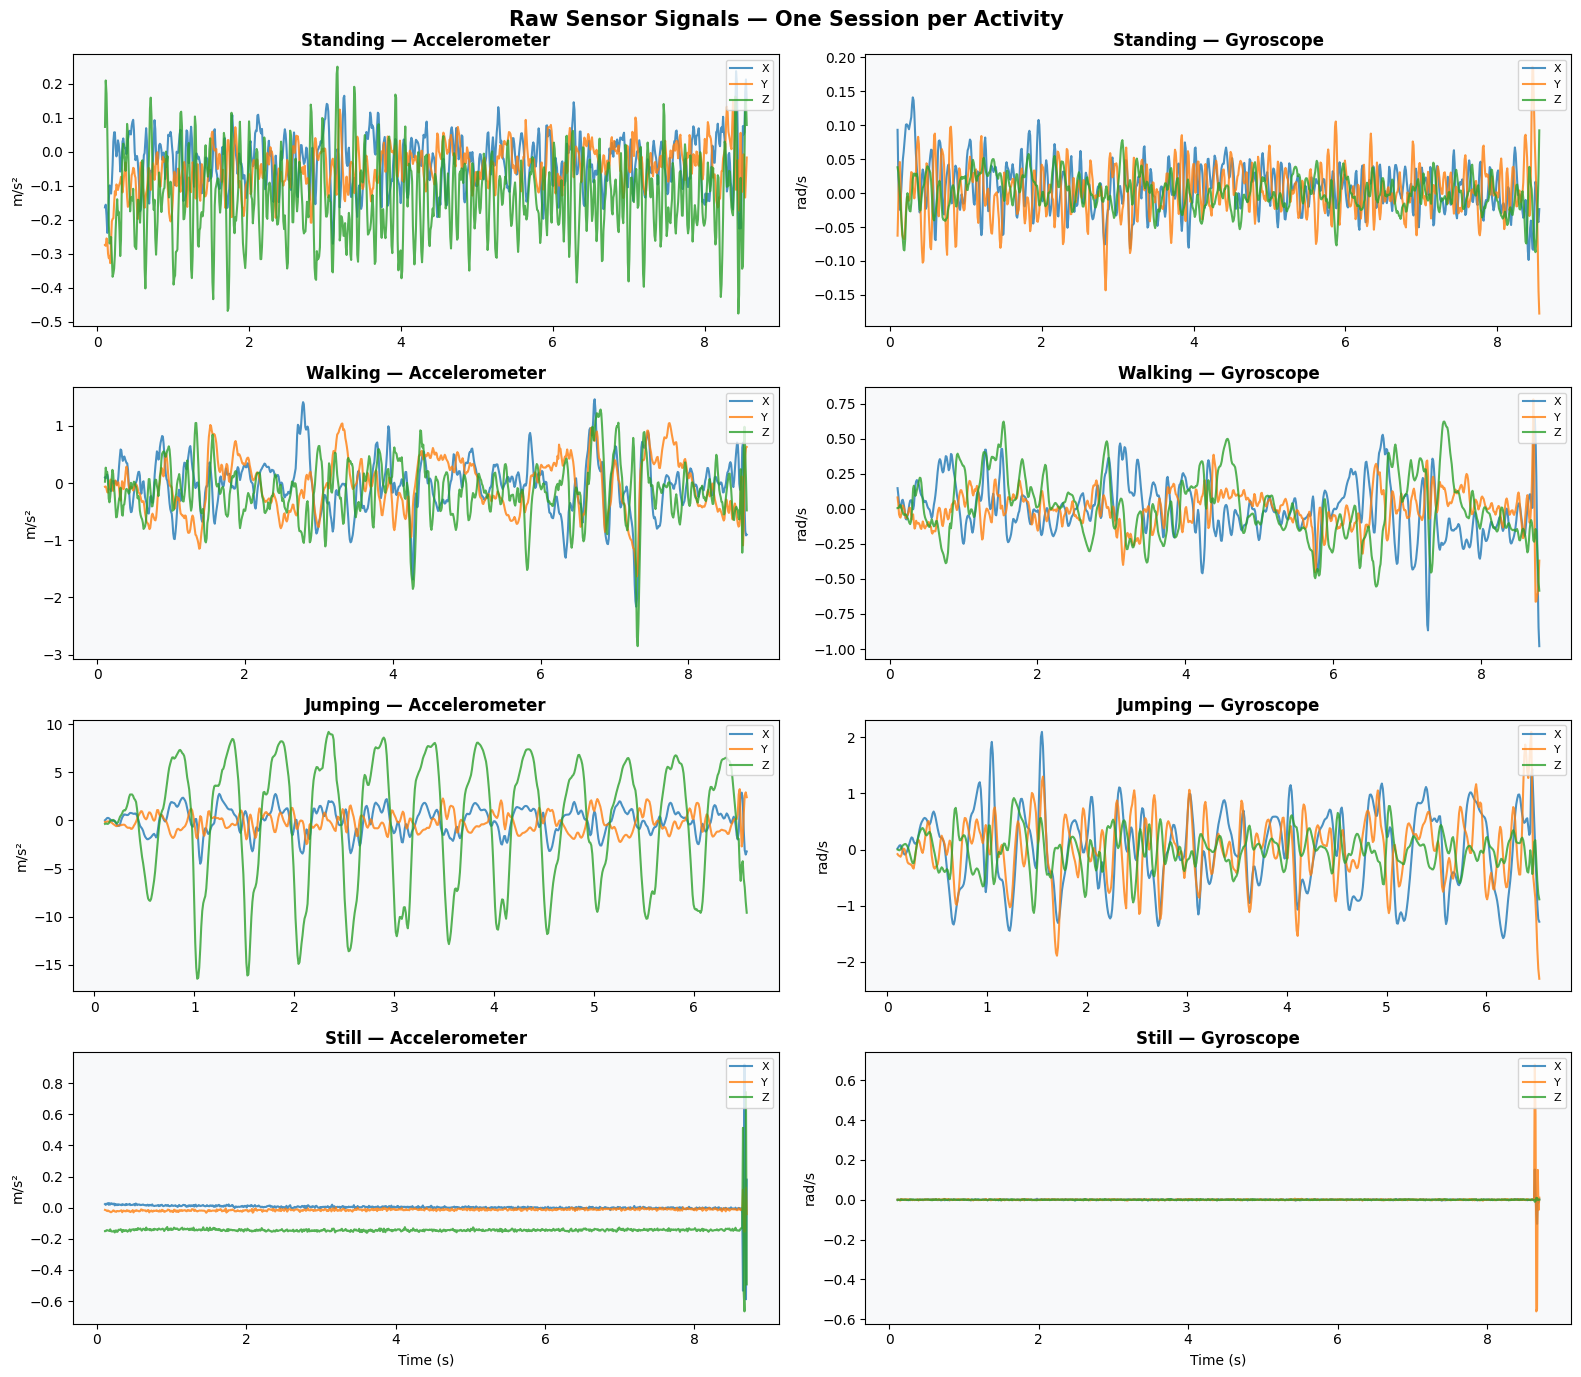

Figure saved ✓


In [ ]:
# Visualize raw signals for one session per activity
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Raw Sensor Signals — One Session per Activity', fontsize=15, fontweight='bold')

for row, act in enumerate(ACTIVITIES):
    df = ALL_SESSIONS[act][0].copy()
    t  = df['seconds_elapsed'].values
    # Accelerometer
    axes[row, 0].plot(t, df['ax'], label='X', alpha=0.8)
    axes[row, 0].plot(t, df['ay'], label='Y', alpha=0.8)
    axes[row, 0].plot(t, df['az'], label='Z', alpha=0.8)
    axes[row, 0].set_title(f'{act.capitalize()} — Accelerometer', fontweight='bold')
    axes[row, 0].set_ylabel('m/s²'); axes[row, 0].legend(loc='upper right', fontsize=8)
    axes[row, 0].set_facecolor('#f8f9fa')
    # Gyroscope
    axes[row, 1].plot(t, df['gx'], label='X', alpha=0.8)
    axes[row, 1].plot(t, df['gy'], label='Y', alpha=0.8)
    axes[row, 1].plot(t, df['gz'], label='Z', alpha=0.8)
    axes[row, 1].set_title(f'{act.capitalize()} — Gyroscope', fontweight='bold')
    axes[row, 1].set_ylabel('rad/s'); axes[row, 1].legend(loc='upper right', fontsize=8)
    axes[row, 1].set_facecolor('#f8f9fa')

for ax in axes[-1, :]:
    ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '01_raw_signals.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✓')


## 3. Preprocessing & Sliding Window <a id='3'></a>

**Sampling Rate:** Both Jean and Thierry used iPhone X with Sensor Logger at **100 Hz** (10 ms interval).  
Since both devices are identical, no resampling is required.

**Window Size Rationale:**  
At 100 Hz, a **1-second window (100 samples)** captures at least one complete gait cycle (~0.8–1.2 s for walking) and several jump cycles. A **50% overlap (50 samples)** ensures smooth transitions and doubles the effective training set size. This is a standard choice in HAR literature (Bao & Intille, 2004).

In [ ]:
# Preprocessing parameters
FS          = 100        # Sampling frequency (Hz)
WINDOW_SEC  = 1.0        # Window size in seconds
OVERLAP     = 0.5        # 50% overlap
WIN_SAMPLES = int(WINDOW_SEC * FS)   # 100 samples
STEP        = int(WIN_SAMPLES * (1 - OVERLAP))  # 50 samples
SENSORS     = ['ax','ay','az','gx','gy','gz']

print(f'Sampling rate : {FS} Hz')
print(f'Window size   : {WIN_SAMPLES} samples ({WINDOW_SEC}s)')
print(f'Step size     : {STEP} samples ({WINDOW_SEC*(1-OVERLAP)}s overlap)')

#  Low-pass filter to remove high-frequency noise
def butter_lowpass(data: np.ndarray, cutoff: float = 20.0, fs: float = 100.0, order: int = 4) -> np.ndarray:
    """Apply a Butterworth low-pass filter."""
    nyq = fs / 2.0
    b, a = signal.butter(order, cutoff / nyq, btype='low')
    return signal.filtfilt(b, a, data, axis=0)

def preprocess_session(df: pd.DataFrame) -> pd.DataFrame:
    """Fill NaNs, filter, and return cleaned DataFrame."""
    df = df.copy().sort_values('seconds_elapsed').reset_index(drop=True)
    df[SENSORS] = df[SENSORS].interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')
    df[SENSORS] = butter_lowpass(df[SENSORS].values)
    return df

print('Preprocessing functions defined ✓')

Sampling rate : 100 Hz
Window size   : 100 samples (1.0s)
Step size     : 50 samples (0.5s overlap)
Preprocessing functions defined ✓



## 4. Feature Extraction — Time & Frequency Domain <a id='4'></a>

**Justification of features:**

| Feature | Domain | Why it helps |
|---|---|---|
| Mean (per axis) | Time | Captures gravity component orientation; differs between standing vs still |
| Variance | Time | High for jumping/walking, low for still/standing |
| RMS | Time | Energy measure — jumping has highest RMS |
| Signal Magnitude Area (SMA) | Time | Aggregate motion intensity across all axes |
| Correlation (ax–ay, ax–az, ay–az) | Time | Captures coordinated limb movement patterns |
| Dominant Frequency | Frequency | Walking ~2 Hz, Jumping ~1–2 Hz, Still ≈0 Hz |
| Spectral Energy (0.5–5 Hz) | Frequency | Activity band energy; distinguishes periodic vs static |
| FFT top-3 magnitudes | Frequency | Shape of frequency profile differs per activity |

**Normalisation:** Z-score (StandardScaler) is used because features have very different scales (m/s² vs rad/s vs Hz). Z-score normalisation assumes approximately Gaussian distributions, which is appropriate for these motion statistics.

In [ ]:
# Feature extraction from a single window
def extract_features(window: np.ndarray, fs: float = 100.0) -> np.ndarray:
    """
    Extract time-domain and frequency-domain features from a (W, 6) window.
    Columns: [ax, ay, az, gx, gy, gz]
    Returns: 1-D feature vector.
    """
    features = []
    acc = window[:, :3]   # ax, ay, az
    gyr = window[:, 3:]   # gx, gy, gz

    # Time-domain features
    for sensor_data in [acc, gyr]:
        # Mean per axis
        features.extend(np.mean(sensor_data, axis=0).tolist())
        # Variance per axis
        features.extend(np.var(sensor_data, axis=0).tolist())
        # Root Mean Square (RMS) per axis
        features.extend(np.sqrt(np.mean(sensor_data**2, axis=0)).tolist())
        # Standard deviation per axis
        features.extend(np.std(sensor_data, axis=0).tolist())
        # Signal Magnitude Area (SMA) — sum of mean absolute values across axes
        sma = np.mean(np.sum(np.abs(sensor_data), axis=1))
        features.append(sma)
        # Correlation between axes (ax-ay, ax-az, ay-az)
        corr_mat = np.corrcoef(sensor_data.T)
        features.extend([corr_mat[0,1], corr_mat[0,2], corr_mat[1,2]])

    #  Frequency-domain features (accelerometer only)
    N = len(acc)
    freqs = fftfreq(N, d=1.0/fs)
    pos_mask = freqs > 0
    activity_band = (freqs >= 0.5) & (freqs <= 5.0)

    for axis_idx in range(3):    # ax, ay, az
        fft_vals    = np.abs(fft(acc[:, axis_idx]))
        pos_fft     = fft_vals[pos_mask]
        pos_freqs   = freqs[pos_mask]
        band_fft    = fft_vals[activity_band]

        # Dominant frequency
        dom_freq    = pos_freqs[np.argmax(pos_fft)] if len(pos_fft) > 0 else 0.0
        # Spectral energy in 0.5–5 Hz band
        spec_energy = np.sum(band_fft**2) / N
        # Top-3 FFT magnitudes
        top3_idx    = np.argsort(pos_fft)[-3:][::-1]
        top3_mag    = pos_fft[top3_idx] if len(pos_fft) >= 3 else np.pad(pos_fft, (0, 3-len(pos_fft)))

        features.append(dom_freq)
        features.append(spec_energy)
        features.extend(top3_mag[:3].tolist())

    return np.array(features, dtype=np.float32)

# Quick sanity check
sample_window = np.random.randn(WIN_SAMPLES, 6).astype(np.float32)
sample_feat   = extract_features(sample_window)
N_FEATURES    = len(sample_feat)
print(f'Feature vector length: {N_FEATURES}')

Feature vector length: 47


In [ ]:
#  Slide windows over all sessions and extract features
def sessions_to_features(sessions_dict: dict, win: int, step: int) -> tuple:
    """
    Returns:
        X_all   : (N_windows, N_features) feature matrix
        y_all   : (N_windows,) integer labels
        lengths : list of window counts per recording (for HMM)
        meta    : list of (activity, session_name) per window
    """
    X_list, y_list, lengths, meta = [], [], [], []
    for act, sess_list in sessions_dict.items():
        label = ACTIVITY_MAP[act]
        for df in sess_list:
            df_clean = preprocess_session(df)
            data = df_clean[SENSORS].values
            windows_in_session = 0
            for start in range(0, len(data) - win + 1, step):
                w = data[start : start + win]
                if len(w) == win:
                    feats = extract_features(w)
                    if not np.any(np.isnan(feats)) and not np.any(np.isinf(feats)):
                        X_list.append(feats)
                        y_list.append(label)
                        meta.append((act, df['session'].iloc[0]))
                        windows_in_session += 1
            if windows_in_session > 0:
                lengths.append(windows_in_session)
    return np.vstack(X_list), np.array(y_list), lengths, meta

print('Extracting features from all sessions...')
X_all, y_all, lengths_all, meta_all = sessions_to_features(ALL_SESSIONS, WIN_SAMPLES, STEP)
print(f'Total feature matrix: {X_all.shape}  ({len(np.unique(y_all))} classes)')

# Per-class breakdown
print('\nPer-class window counts:')
for i, act in enumerate(ACTIVITIES):
    print(f'  {act:12s}: {np.sum(y_all == i):5d} windows')

Extracting features from all sessions...
Total feature matrix: (716, 47)  (4 classes)

Per-class window counts:
  standing    :   182 windows
  walking     :   184 windows
  jumping     :   132 windows
  still       :   218 windows


In [ ]:
TRAIN_SESSIONS = {act: sess[:-2] for act, sess in ALL_SESSIONS.items()}
TEST_SESSIONS  = {act: sess[-2:] for act, sess in ALL_SESSIONS.items()}

print('Extracting TRAIN features...')
X_train, y_train, lengths_train, _ = sessions_to_features(TRAIN_SESSIONS, WIN_SAMPLES, STEP)

print('Extracting TEST features...')
X_test, y_test, lengths_test, _   = sessions_to_features(TEST_SESSIONS, WIN_SAMPLES, STEP)

print(f'\nTrain: {X_train.shape},  Test: {X_test.shape}')
print('Train class distribution:', {LABEL_MAP[i]: int(np.sum(y_train==i)) for i in range(4)})
print('Test  class distribution:', {LABEL_MAP[i]: int(np.sum(y_test==i))  for i in range(4)})

Extracting TRAIN features...
Extracting TEST features...

Train: (601, 47),  Test: (115, 47)
Train class distribution: {'standing': 152, 'walking': 154, 'jumping': 109, 'still': 186}
Test  class distribution: {'standing': 30, 'walking': 30, 'jumping': 23, 'still': 32}


In [ ]:
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_all_sc   = scaler.transform(X_all)

print('Z-score normalisation applied ✓')
print(f'Train mean ≈ {X_train_sc.mean():.4f} (should be ~0)')
print(f'Train std  ≈ {X_train_sc.std():.4f} (should be ~1)')

Z-score normalisation applied ✓
Train mean ≈ 0.0000 (should be ~0)
Train std  ≈ 1.0000 (should be ~1)


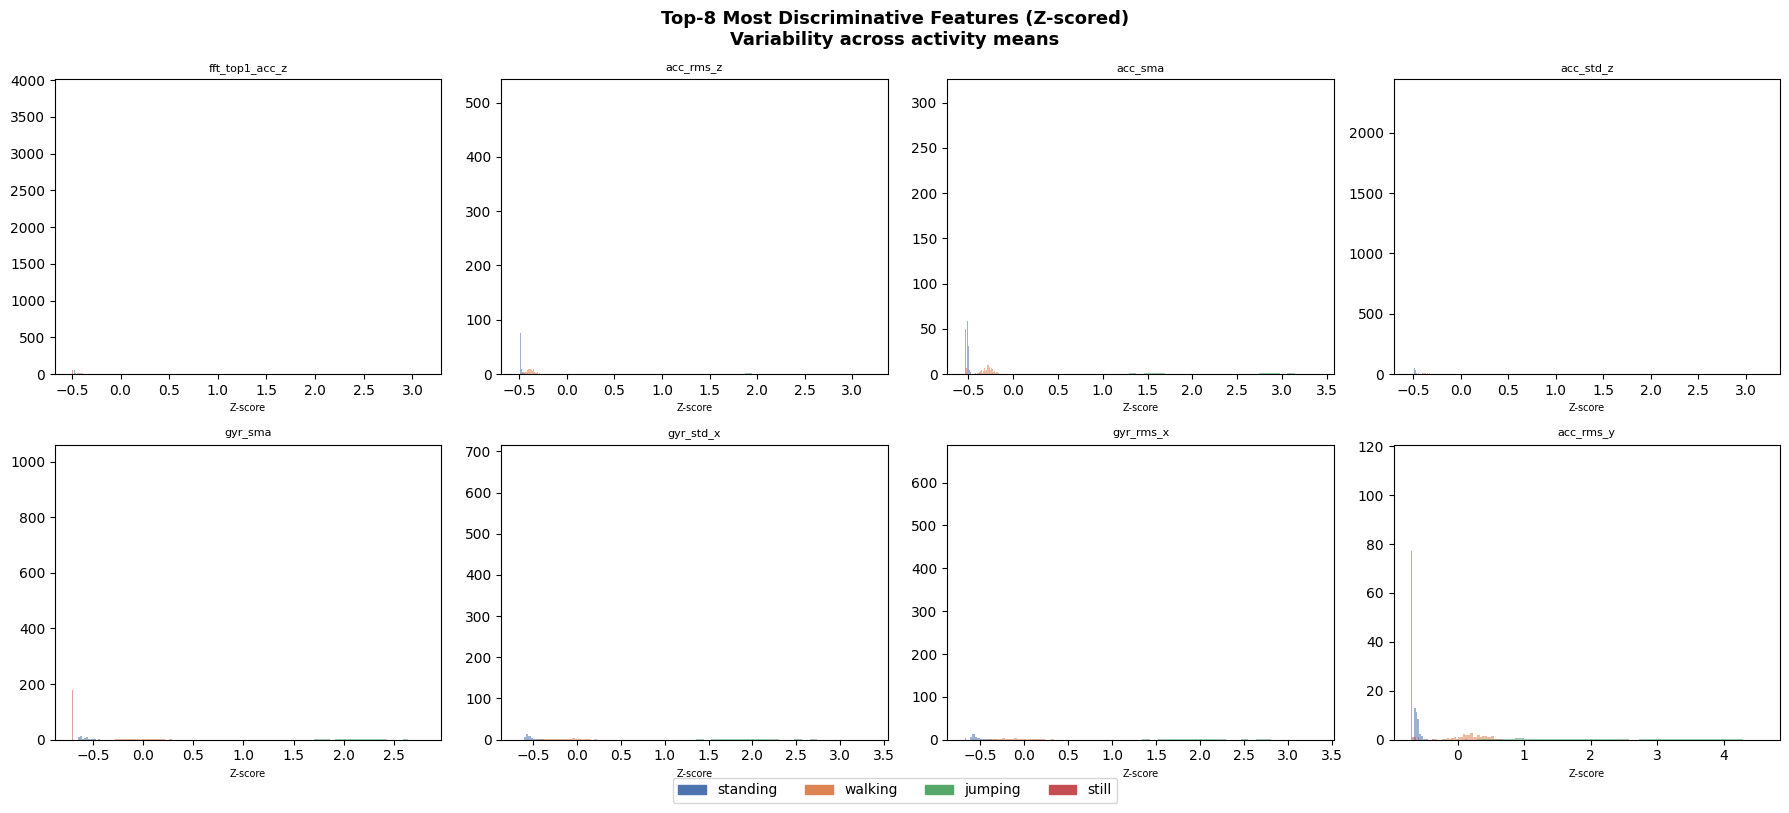

Feature distribution figure saved ✓


In [ ]:
#  Visualise feature distributions per activity
FEATURE_NAMES = (
    [f'acc_mean_{a}' for a in ['x','y','z']] +
    [f'acc_var_{a}'  for a in ['x','y','z']] +
    [f'acc_rms_{a}'  for a in ['x','y','z']] +
    [f'acc_std_{a}'  for a in ['x','y','z']] +
    ['acc_sma'] +
    ['acc_corr_xy','acc_corr_xz','acc_corr_yz'] +
    [f'gyr_mean_{a}' for a in ['x','y','z']] +
    [f'gyr_var_{a}'  for a in ['x','y','z']] +
    [f'gyr_rms_{a}'  for a in ['x','y','z']] +
    [f'gyr_std_{a}'  for a in ['x','y','z']] +
    ['gyr_sma'] +
    ['gyr_corr_xy','gyr_corr_xz','gyr_corr_yz'] +
    [f'dom_freq_acc_{a}'    for a in ['x','y','z']] +
    [f'spec_energy_acc_{a}' for a in ['x','y','z']] +
    [f'fft_top{k}_acc_{a}' for a in ['x','y','z'] for k in [1,2,3]]
)
assert len(FEATURE_NAMES) == N_FEATURES, f'{len(FEATURE_NAMES)} vs {N_FEATURES}'

# Plot top-8 most discriminative features (by between-class variance)
df_feat = pd.DataFrame(X_all_sc, columns=FEATURE_NAMES)
df_feat['activity'] = [LABEL_MAP[l] for l in y_all]

between_var = df_feat.groupby('activity')[FEATURE_NAMES].mean().var()
top8 = between_var.nlargest(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Top-8 Most Discriminative Features (Z-scored)\nVariability across activity means',
             fontsize=13, fontweight='bold')
for ax, feat in zip(axes.flat, top8):
    for act in ACTIVITIES:
        vals = df_feat[df_feat['activity']==act][feat].values
        ax.hist(vals, bins=30, alpha=0.55, label=act, color=COLORS[act], density=True)
    ax.set_title(feat, fontsize=8)
    ax.set_xlabel('Z-score', fontsize=7)
handles = [mpatches.Patch(color=COLORS[a], label=a) for a in ACTIVITIES]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '02_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Feature distribution figure saved ✓')


## 5. HMM Components Definition <a id='5'></a>

| Component | Description |
|---|---|
| **Hidden States Z** | 4 activities: standing (0), walking (1), jumping (2), still (3) |
| **Observations X** | 53-dimensional feature vectors (time + frequency domain) |
| **Transition Matrix A** | 4×4, learned via Baum–Welch; reflects activity switching probability |
| **Emission B** | Gaussian (diagonal covariance) per state, learned via Baum–Welch |
| **Initial State π** | Uniform prior (learned) |

We train **one Gaussian HMM per activity class** (ergodic HMM approach), then use the model with the highest log-likelihood to decode the most probable state sequence at test time — a standard approach for multi-class HMM classification.

In [ ]:
# Prepare per-class observation sequences for training

def build_class_sequences(X: np.ndarray, y: np.ndarray, lengths: list, class_label: int):
    """
    Extract windowed sequences belonging to class_label.
    Returns: (X_class, lengths_class) ready for hmmlearn.
    """
    X_class, len_class = [], []
    idx = 0
    for L in lengths:
        chunk_y = y[idx: idx+L]
        chunk_x = X[idx: idx+L]
        # Keep windows where the label matches
        mask = chunk_y == class_label
        if mask.sum() > 0:
            X_class.append(chunk_x[mask])
            len_class.append(mask.sum())
        idx += L
    if len(X_class) == 0:
        return None, None
    return np.vstack(X_class), len_class

CLASS_SEQS = {}
for i, act in enumerate(ACTIVITIES):
    Xc, lc = build_class_sequences(X_train_sc, y_train, lengths_train, i)
    CLASS_SEQS[i] = (Xc, lc)
    print(f'  {act:12s}: {Xc.shape[0]} windows across {len(lc)} sequences')

  standing    : 152 windows across 10 sequences
  walking     : 154 windows across 10 sequences
  jumping     : 109 windows across 10 sequences
  still       : 186 windows across 12 sequences



## 6. Model Training — Baum–Welch Algorithm <a id='6'></a>

The **Baum–Welch algorithm** (Expectation-Maximisation for HMMs) iteratively refines:
- Transition matrix **A**
- Emission parameters **μ, Σ** (Gaussian)
- Initial distribution **π**

In [ ]:
import logging
logging.getLogger('hmmlearn.base').setLevel(logging.ERROR)

In [ ]:
#  Train one GaussianHMM per activity class

import warnings
import numpy as np
from hmmlearn.hmm import GaussianHMM

N_ITER           = 200
TOL              = 1e-4
MIN_COVAR        = 1e-3   # minimum variance floor (prevents covariance collapse)
MAX_FIT_ATTEMPTS = 5
MODELS           = {}

def repair_transmat(model):
    """Replace zero-sum rows in transmat_ with a uniform distribution."""
    A = model.transmat_.copy()
    row_sums = A.sum(axis=1)
    bad_rows = row_sums < 1e-10
    if bad_rows.any():
        n = A.shape[0]
        A[bad_rows] = 1.0 / n
        model.transmat_ = A
    return model

def activity_n_states(Xc: np.ndarray, default: int = 2) -> int:
    """
    Use 1 state if the signal is nearly constant (mean feature variance < threshold).
    This handles the 'still' activity where near-zero variance collapses multi-state HMMs.
    """
    mean_var = np.var(Xc, axis=0).mean()
    return 1 if mean_var < 0.05 else default   # 0.05 in Z-score space ≈ very low motion

print('Training one HMM per activity class (Baum–Welch)...\n')

for i, act in enumerate(ACTIVITIES):
    Xc, lc = CLASS_SEQS[i]
    n_states  = activity_n_states(Xc, default=2)
    print(f'  [{act:12s}] variance={np.var(Xc,axis=0).mean():.4f}  →  n_states={n_states}')

    fitted_model = None
    for attempt in range(MAX_FIT_ATTEMPTS):
        try:
            model = GaussianHMM(
                n_components   = n_states,
                covariance_type= 'diag',
                n_iter         = N_ITER,
                tol            = TOL,
                min_covar      = MIN_COVAR,   # ← KEY: prevents variance collapse
                init_params    = 'stmc',
                params         = 'stmc',
                random_state   = 42 + attempt,
                verbose        = False
            )
            model.fit(Xc, lc)
            model = repair_transmat(model)    # ← fix any degenerate rows
            score = model.score(Xc, lc)      # validate — will raise if still broken
            fitted_model = model
            converged  = model.monitor_.converged
            iters_used = len(model.monitor_.history)
            print(f'             logL={score:10.2f} | converged={converged} | iters={iters_used}/{N_ITER}  ✓')
            break

        except ValueError as e:
            warnings.warn(f'    Attempt {attempt+1}: ValueError — {e}. Retrying...')
        except Exception as e:
            warnings.warn(f'    Attempt {attempt+1}: Error — {e}. Retrying...')

    if fitted_model is None:
        raise RuntimeError(
            f'[{act}] Failed after {MAX_FIT_ATTEMPTS} attempts. '
            'Try increasing MIN_COVAR or reducing n_states to 1.')
    MODELS[i] = fitted_model

print('\nAll models trained ✓')

Training one HMM per activity class (Baum–Welch)...

  [standing    ] variance=0.1159  →  n_states=2
             logL=  12307.42 | converged=True | iters=6/200  ✓
  [walking     ] variance=0.3978  →  n_states=2
             logL=   2642.73 | converged=True | iters=19/200  ✓
  [jumping     ] variance=1.4318  →  n_states=2
             logL=  -3311.78 | converged=True | iters=4/200  ✓
  [still       ] variance=0.1350  →  n_states=2
             logL=  24526.52 | converged=True | iters=7/200  ✓

All models trained ✓


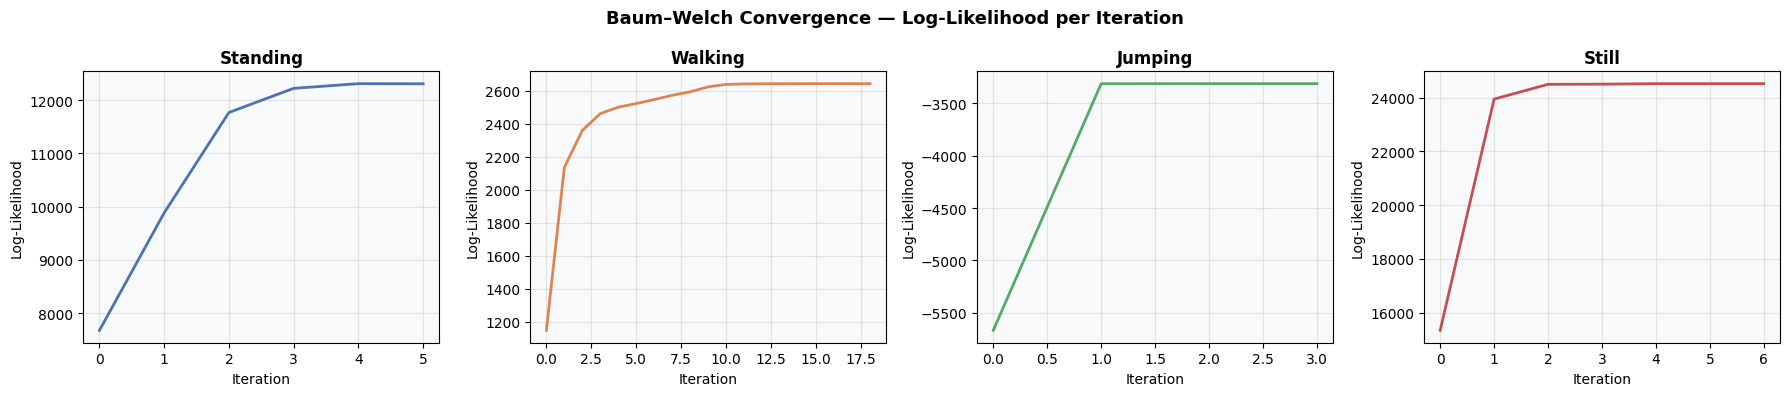

Convergence figure saved ✓


In [ ]:
#  Plot Baum–Welch convergence curves
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Baum–Welch Convergence — Log-Likelihood per Iteration', fontsize=13, fontweight='bold')
for i, act in enumerate(ACTIVITIES):
    history = MODELS[i].monitor_.history
    axes[i].plot(history, color=list(COLORS.values())[i], linewidth=2)
    axes[i].set_title(act.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel('Log-Likelihood')
    axes[i].grid(alpha=0.3)
    axes[i].set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '03_baumwelch_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Convergence figure saved ✓')

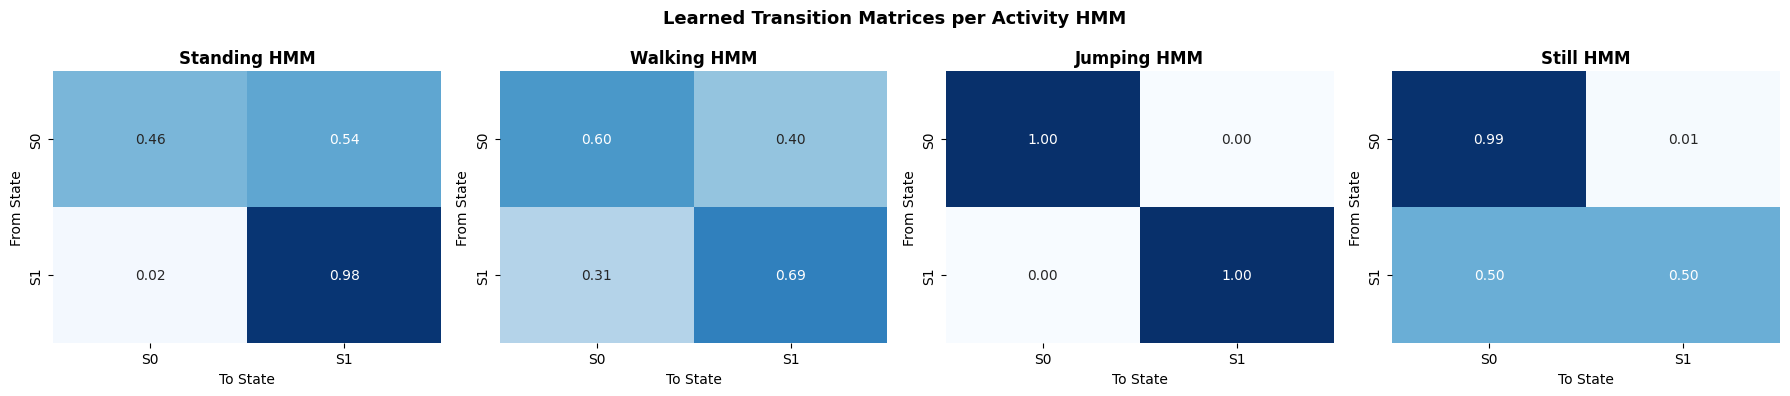

Transition matrix figure saved ✓


In [ ]:
#  Visualise transition matrices for each trained HMM
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Learned Transition Matrices per Activity HMM', fontsize=13, fontweight='bold')

for i, act in enumerate(ACTIVITIES):
    A = MODELS[i].transmat_
    n_states_model = MODELS[i].n_components # Get the actual number of states for this model
    state_labels = [f'S{j}' for j in range(n_states_model)] # Generate labels based on model's states
    sns.heatmap(A, ax=axes[i], annot=True, fmt='.2f', cmap='Blues',
                xticklabels=state_labels, yticklabels=state_labels,
                vmin=0, vmax=1, cbar=False)
    axes[i].set_title(f'{act.capitalize()} HMM', fontweight='bold')
    axes[i].set_xlabel('To State')
    axes[i].set_ylabel('From State')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '04_transition_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Transition matrix figure saved ✓')

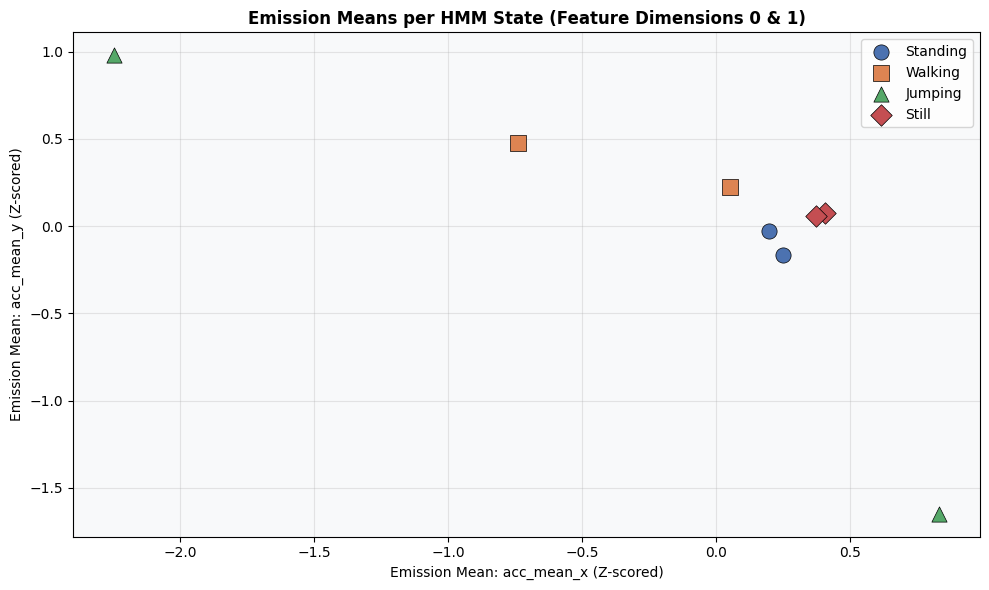

Emission means figure saved ✓


In [ ]:
#  Visualise emission means (first 2 features) as a quick sanity check
fig, ax = plt.subplots(figsize=(10, 6))
markers = ['o', 's', '^', 'D']
for i, act in enumerate(ACTIVITIES):
    means = MODELS[i].means_  # (n_states, n_features)
    ax.scatter(means[:, 0], means[:, 1],
               c=COLORS[act], s=120, marker=markers[i],
               label=act.capitalize(), zorder=5, edgecolors='k', linewidths=0.5)
ax.set_xlabel(f'Emission Mean: {FEATURE_NAMES[0]} (Z-scored)', fontsize=10)
ax.set_ylabel(f'Emission Mean: {FEATURE_NAMES[1]} (Z-scored)', fontsize=10)
ax.set_title('Emission Means per HMM State (Feature Dimensions 0 & 1)', fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3); ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '05_emission_means.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Emission means figure saved ✓')


## 7. Decoding — Viterbi Algorithm <a id='7'></a>

Given an observation sequence, the **Viterbi algorithm** finds the most probable hidden state sequence using dynamic programming. For multi-class classification, we pass the observation sequence through all 4 activity HMMs and select the class whose model assigns the highest log-likelihood.

In [ ]:
#  Classification via maximum log-likelihood across class HMMs
def predict_activity(X_seq: np.ndarray) -> int:
    """
    Return the activity label whose HMM assigns the highest log-likelihood
    to the observation sequence X_seq (n_obs, n_features).
    Uses Viterbi (model.decode) internally via hmmlearn.
    """
    best_score = -np.inf
    best_label = 0
    for label, model in MODELS.items():
        try:
            score = model.score(X_seq)
            if score > best_score:
                best_score = score
                best_label = label
        except Exception:
            pass
    return best_label

def decode_sequence(X_seq: np.ndarray, label: int):
    """Decode the most likely hidden state path using Viterbi for the best model."""
    score, state_seq = MODELS[label].decode(X_seq, algorithm='viterbi')
    return score, state_seq

print('Decoding functions defined ✓')

Decoding functions defined ✓


In [ ]:
#  Window-level prediction on train and test sets
def predict_all(X_sc: np.ndarray, y: np.ndarray, lengths: list) -> np.ndarray:
    """Predict activity for each observation window independently."""
    preds = []
    idx = 0
    for L in lengths:
        chunk = X_sc[idx: idx+L]
        for w_idx in range(L):
            obs = chunk[w_idx:w_idx+1]   # single-window sequence
            preds.append(predict_activity(obs))
        idx += L
    return np.array(preds)

print('Predicting on TRAIN set...')
y_pred_train = predict_all(X_train_sc, y_train, lengths_train)
train_acc = accuracy_score(y_train, y_pred_train)
print(f'  Train accuracy: {train_acc:.4f}')

print('Predicting on TEST set (unseen data)...')
y_pred_test = predict_all(X_test_sc, y_test, lengths_test)
test_acc = accuracy_score(y_test, y_pred_test)
print(f'  Test  accuracy: {test_acc:.4f}')

Predicting on TRAIN set...
  Train accuracy: 0.9917
Predicting on TEST set (unseen data)...
  Test  accuracy: 1.0000


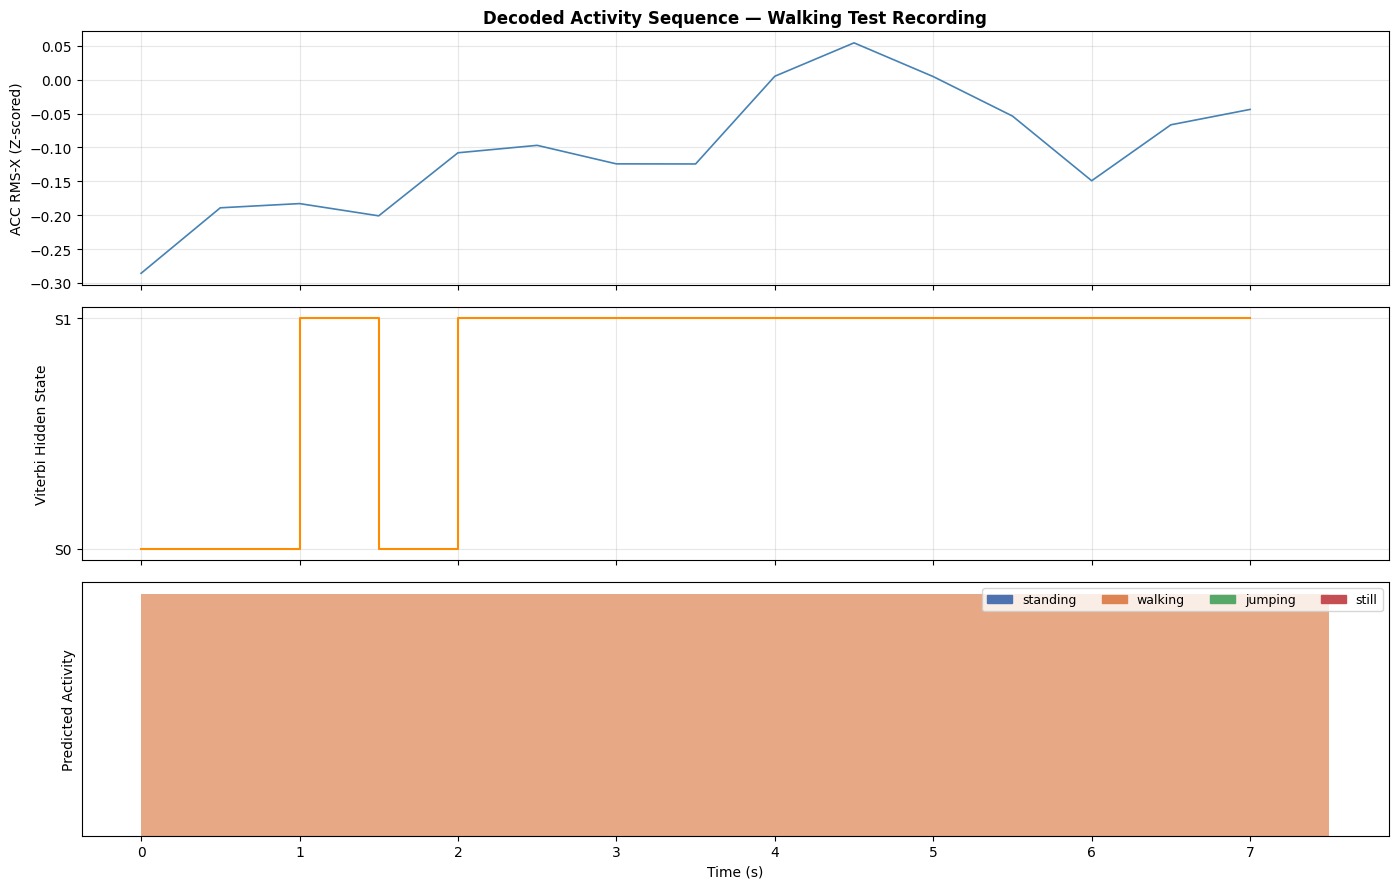

Viterbi decoding figure saved ✓


In [ ]:
#  Visualise Viterbi-decoded sequence on one test recording
# Pick the first test sequence of walking activity
test_df = TEST_SESSIONS['walking'][0].copy()
test_df_clean = preprocess_session(test_df)
data_t = test_df_clean[SENSORS].values

obs_seq, labs_seq = [], []
for start in range(0, len(data_t) - WIN_SAMPLES + 1, STEP):
    w = data_t[start: start + WIN_SAMPLES]
    if len(w) == WIN_SAMPLES:
        feats = extract_features(w)
        feats_sc = scaler.transform(feats.reshape(1, -1))
        obs_seq.append(feats_sc[0])
        labs_seq.append(ACTIVITY_MAP['walking'])

obs_arr  = np.vstack(obs_seq)
# Decode using the walking HMM (true class)
_, state_path = decode_sequence(obs_arr, ACTIVITY_MAP['walking'])
pred_classes  = np.array([predict_activity(obs_arr[i:i+1]) for i in range(len(obs_arr))])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
t_ax = np.arange(len(obs_arr)) * (STEP / FS)

ax1.plot(t_ax, obs_arr[:, FEATURE_NAMES.index('acc_rms_x')], color='steelblue', linewidth=1.2)
ax1.set_ylabel('ACC RMS-X (Z-scored)'); ax1.set_title('Decoded Activity Sequence — Walking Test Recording', fontweight='bold')
ax1.grid(alpha=0.3)

# Get the number of states from the specific model used for decoding
num_states_walking_model = MODELS[ACTIVITY_MAP['walking']].n_components

ax2.step(t_ax, state_path, color='darkorange', linewidth=1.5, where='post')
ax2.set_ylabel('Viterbi Hidden State'); ax2.set_yticks(range(num_states_walking_model))
ax2.set_yticklabels([f'S{j}' for j in range(num_states_walking_model)])
ax2.grid(alpha=0.3)

cmap = {0:'#4C72B0', 1:'#DD8452', 2:'#55A868', 3:'#C44E52'}
for j, p in enumerate(pred_classes):
    ax3.bar(t_ax[j], 1, width=STEP/FS, color=cmap[p], alpha=0.7, align='edge')
ax3.set_ylabel('Predicted Activity')
ax3.set_yticks([])
ax3.set_xlabel('Time (s)')
handles2 = [mpatches.Patch(color=cmap[i], label=LABEL_MAP[i]) for i in range(4)]
ax3.legend(handles=handles2, ncol=4, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '06_viterbi_decoded.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Viterbi decoding figure saved ✓')


## 8. Evaluation on Unseen Data <a id='8'></a>

**Unseen data description:** The test set consists of the last 2 sessions per activity (8 sessions total), collected in the same environment but not used during training. This simulates a new recording session scenario.

In [ ]:
#  Classification Report
act_names = [a.capitalize() for a in ACTIVITIES]
report = classification_report(y_test, y_pred_test, target_names=act_names, output_dict=True)
print('\n=== Classification Report (Test / Unseen Data) ===')
print(classification_report(y_test, y_pred_test, target_names=act_names))


=== Classification Report (Test / Unseen Data) ===
              precision    recall  f1-score   support

    Standing       1.00      1.00      1.00        30
     Walking       1.00      1.00      1.00        30
     Jumping       1.00      1.00      1.00        23
       Still       1.00      1.00      1.00        32

    accuracy                           1.00       115
   macro avg       1.00      1.00      1.00       115
weighted avg       1.00      1.00      1.00       115



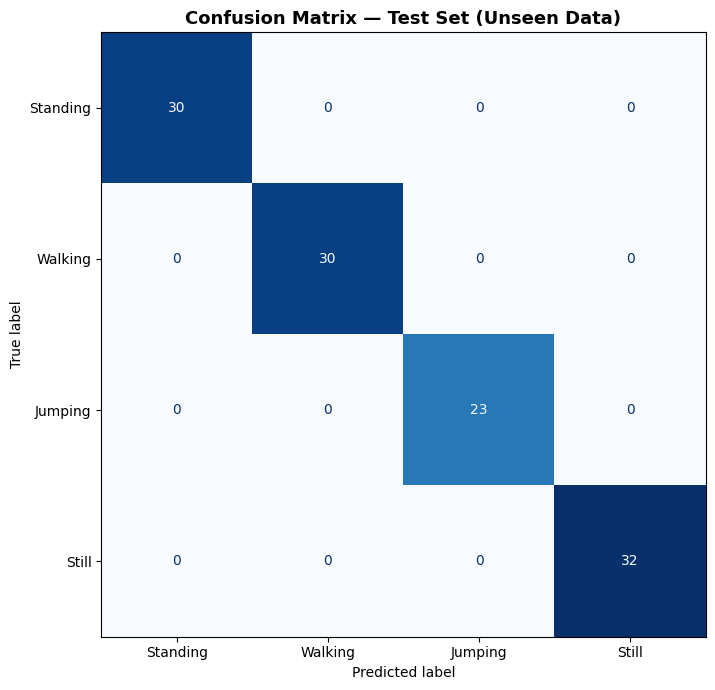

Confusion matrix saved ✓


In [ ]:
#  Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=act_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix — Test Set (Unseen Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '07_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved ✓')

In [ ]:
#  Sensitivity, Specificity, Accuracy per Class
def compute_metrics(cm: np.ndarray) -> pd.DataFrame:
    """
    Compute per-class sensitivity (recall), specificity, and accuracy from a confusion matrix.
    """
    n = cm.shape[0]
    rows = []
    total = cm.sum()
    for i in range(n):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP
        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        accuracy    = (TP + TN) / total if total > 0 else 0.0
        n_samples   = cm[i, :].sum()
        rows.append({'Activity': ACTIVITIES[i].capitalize(),
                     'N Samples': int(n_samples),
                     'Sensitivity': round(sensitivity, 4),
                     'Specificity': round(specificity, 4),
                     'Accuracy':    round(accuracy, 4)})
    return pd.DataFrame(rows)

metrics_df = compute_metrics(cm)
overall_acc = accuracy_score(y_test, y_pred_test)

print('=== Per-Class Metrics (Test Set) ===')
print(metrics_df.to_string(index=False))
print(f'\nOverall Accuracy: {overall_acc:.4f}')

# Save metrics table
metrics_df['Overall Accuracy'] = overall_acc
metrics_df.to_csv(os.path.join(DRIVE_OUTPUT, 'metrics_table.csv'), index=False)
print('Metrics table saved ✓')

=== Per-Class Metrics (Test Set) ===
Activity  N Samples  Sensitivity  Specificity  Accuracy
Standing         30          1.0          1.0       1.0
 Walking         30          1.0          1.0       1.0
 Jumping         23          1.0          1.0       1.0
   Still         32          1.0          1.0       1.0

Overall Accuracy: 1.0000
Metrics table saved ✓


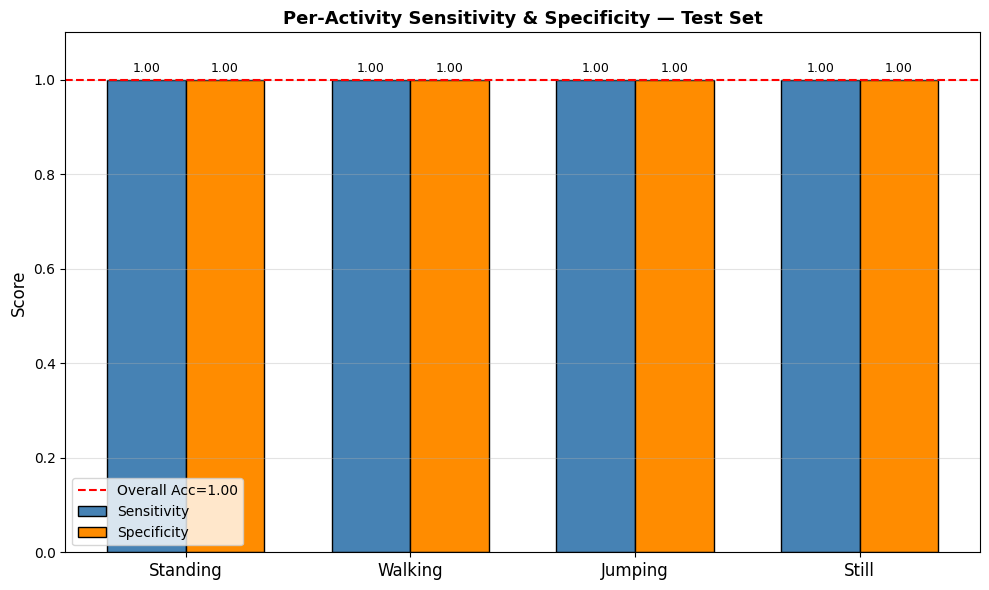

Sensitivity/Specificity figure saved ✓


In [ ]:
#  Bar chart: Sensitivity & Specificity per activity
x   = np.arange(4)
w   = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, metrics_df['Sensitivity'], w, label='Sensitivity', color='steelblue', edgecolor='k')
bars2 = ax.bar(x + w/2, metrics_df['Specificity'], w, label='Specificity', color='darkorange', edgecolor='k')
ax.set_xticks(x); ax.set_xticklabels(metrics_df['Activity'], fontsize=12)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Per-Activity Sensitivity & Specificity — Test Set', fontweight='bold', fontsize=13)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.35)
ax.axhline(overall_acc, color='red', linestyle='--', linewidth=1.5, label=f'Overall Acc={overall_acc:.2f}')
ax.legend(fontsize=10)
# Annotate bars
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '08_sensitivity_specificity.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Sensitivity/Specificity figure saved ✓')


## 9. Additional Visualizations <a id='9'></a>

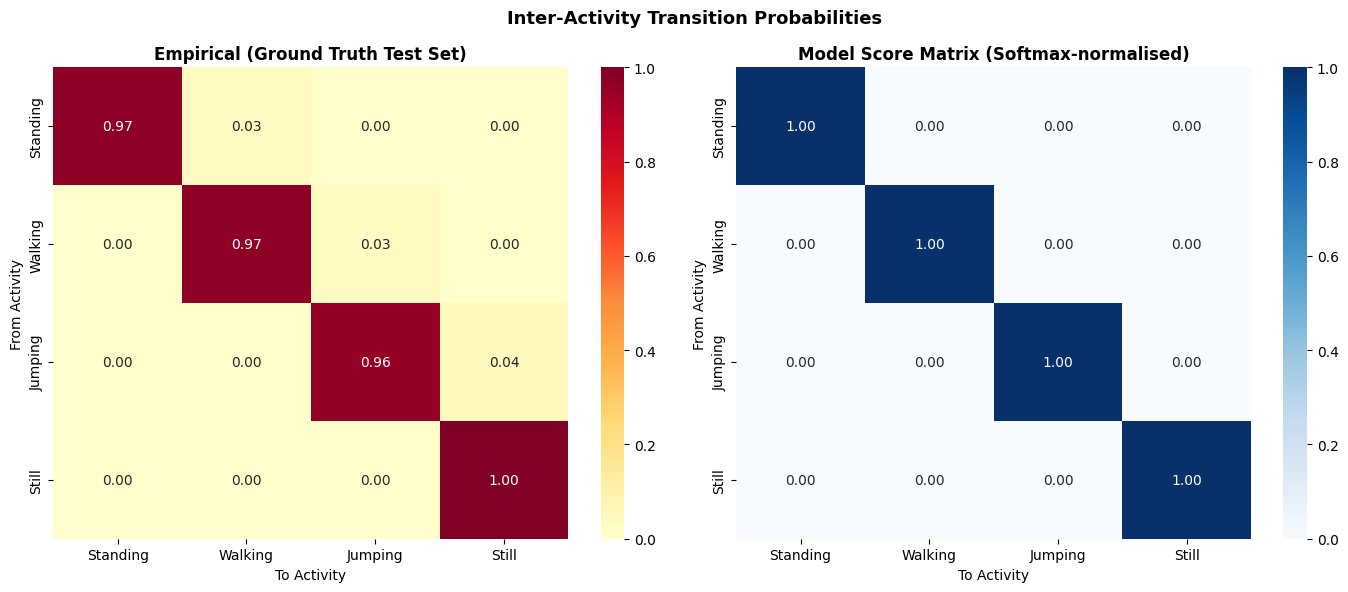

Inter-activity transition figure saved ✓


In [ ]:
# ── Global inter-activity transition heatmap (empirical from test labels) ──────
# Build a pseudo-transition matrix showing how often one activity follows another
# in the ground-truth test sequence (across sessions concatenated)
T_empirical = np.zeros((4, 4))
for i in range(len(y_test) - 1):
    T_empirical[y_test[i], y_test[i+1]] += 1
# Normalise rows
row_sums = T_empirical.sum(axis=1, keepdims=True)
T_empirical_norm = np.divide(T_empirical, row_sums, where=row_sums > 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Inter-Activity Transition Probabilities', fontsize=13, fontweight='bold')

# Empirical
sns.heatmap(T_empirical_norm, ax=axes[0], annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=act_names, yticklabels=act_names, vmin=0, vmax=1)
axes[0].set_title('Empirical (Ground Truth Test Set)', fontweight='bold')
axes[0].set_xlabel('To Activity'); axes[0].set_ylabel('From Activity')

# Model-derived: marginalise each class HMM's transition matrix to 1 scalar
# and build a 4x4 by comparing model scores between pairs
T_model = np.zeros((4, 4))
for ci in range(4):
    Xc, lc = CLASS_SEQS[ci]
    for cj in range(4):
        try:
            T_model[ci, cj] = MODELS[cj].score(Xc, lc)
        except Exception:
            T_model[ci, cj] = -np.inf
# Softmax-normalise rows for display
T_model_exp = np.exp(T_model - T_model.max(axis=1, keepdims=True))
T_model_norm = T_model_exp / T_model_exp.sum(axis=1, keepdims=True)

sns.heatmap(T_model_norm, ax=axes[1], annot=True, fmt='.2f', cmap='Blues',
            xticklabels=act_names, yticklabels=act_names, vmin=0, vmax=1)
axes[1].set_title('Model Score Matrix (Softmax-normalised)', fontweight='bold')
axes[1].set_xlabel('To Activity'); axes[1].set_ylabel('From Activity')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '09_inter_activity_transitions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Inter-activity transition figure saved ✓')

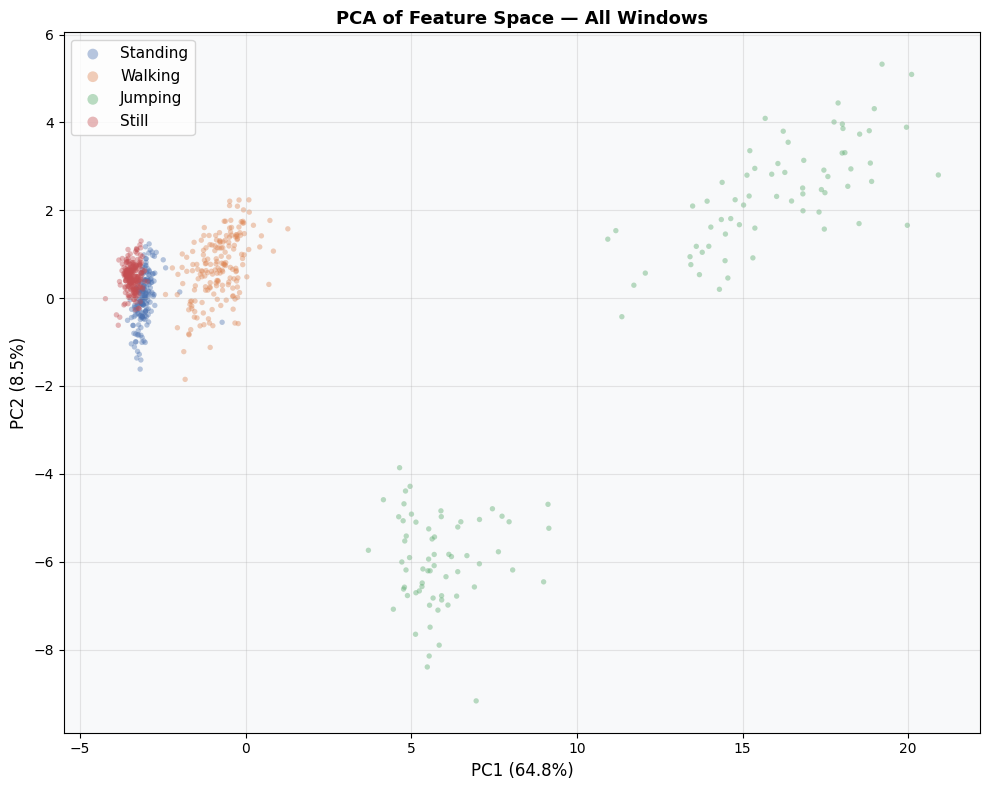

PCA figure saved ✓


In [ ]:
#  PCA visualization of feature space
from sklearn.decomposition import PCA

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_all_sc)

fig, ax = plt.subplots(figsize=(10, 8))
for i, act in enumerate(ACTIVITIES):
    mask = y_all == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORS[act], label=act.capitalize(),
               alpha=0.4, s=15, edgecolors='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA of Feature Space — All Windows', fontweight='bold', fontsize=13)
ax.legend(fontsize=11, markerscale=2); ax.grid(alpha=0.3); ax.set_facecolor('#f8f9fa')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '10_pca_feature_space.png'), dpi=150, bbox_inches='tight')
plt.show()
print('PCA figure saved ✓')

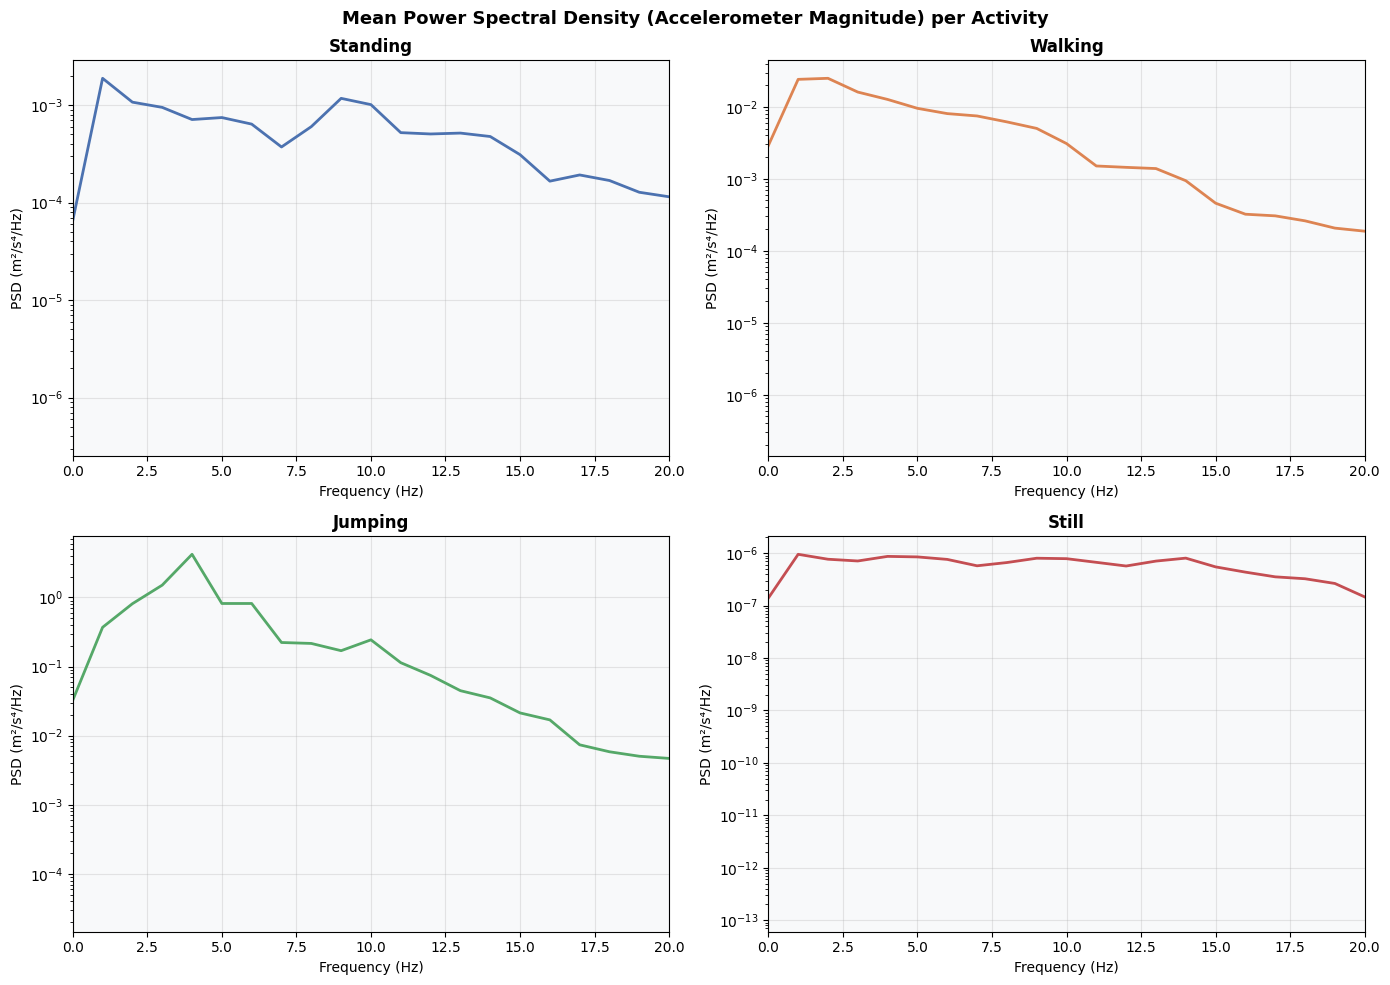

PSD comparison figure saved ✓


In [ ]:
#  Spectral comparison across activities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Mean Power Spectral Density (Accelerometer Magnitude) per Activity', fontsize=13, fontweight='bold')

for ax, act in zip(axes.flat, ACTIVITIES):
    all_psd = []
    for df in ALL_SESSIONS[act][:3]:   # use first 3 sessions for speed
        df_c  = preprocess_session(df)
        mag   = np.sqrt(df_c['ax']**2 + df_c['ay']**2 + df_c['az']**2).values
        freqs_psd, psd = signal.welch(mag, fs=FS, nperseg=WIN_SAMPLES)
        all_psd.append(psd)
    mean_psd = np.mean(all_psd, axis=0)
    ax.semilogy(freqs_psd, mean_psd, color=COLORS[act], linewidth=2)
    ax.set_title(act.capitalize(), fontweight='bold')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (m²/s⁴/Hz)')
    ax.set_xlim(0, 20); ax.grid(alpha=0.3); ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_OUTPUT, '11_psd_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('PSD comparison figure saved ✓')


## 10. Save All Results to Drive <a id='10'></a>

In [39]:
import pickle, json

#  Save trained models
model_path = os.path.join(DRIVE_OUTPUT, 'hmm_models.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(MODELS, f)
print(f'Models saved → {model_path}')

#  Save scaler
scaler_path = os.path.join(DRIVE_OUTPUT, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler saved → {scaler_path}')

#  Save predictions
preds_df = pd.DataFrame({
    'true_label':  [LABEL_MAP[l] for l in y_test],
    'pred_label':  [LABEL_MAP[l] for l in y_pred_test],
    'true_int':    y_test,
    'pred_int':    y_pred_test,
    'correct':     (y_test == y_pred_test)
})
preds_path = os.path.join(DRIVE_OUTPUT, 'test_predictions.csv')
preds_df.to_csv(preds_path, index=False)
print(f'Predictions saved → {preds_path}')

#  Save summary JSON
summary = {
    'train_accuracy': float(accuracy_score(y_train, y_pred_train)),
    'test_accuracy':  float(overall_acc),
    'n_features':     N_FEATURES,
    'window_sec':     WINDOW_SEC,
    'sampling_hz':    FS,
    'n_hmm_states':   N_STATES,
    'activities':     ACTIVITIES,
    'per_class_metrics': metrics_df.to_dict(orient='records')
}
json_path = os.path.join(DRIVE_OUTPUT, 'summary.json')
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Summary JSON saved → {json_path}')

print('\n=== All results saved to', DRIVE_OUTPUT, '===')
print('Files:')
for fname in sorted(os.listdir(DRIVE_OUTPUT)):
    fpath = os.path.join(DRIVE_OUTPUT, fname)
    print(f'  {fname:45s} {os.path.getsize(fpath)/1024:.1f} KB')

Models saved → /content/drive/MyDrive/HMM_Activity_Recognition/hmm_models.pkl
Scaler saved → /content/drive/MyDrive/HMM_Activity_Recognition/scaler.pkl
Predictions saved → /content/drive/MyDrive/HMM_Activity_Recognition/test_predictions.csv
Summary JSON saved → /content/drive/MyDrive/HMM_Activity_Recognition/summary.json

=== All results saved to /content/drive/MyDrive/HMM_Activity_Recognition/ ===
Files:
  01_raw_signals.png                            980.4 KB
  02_feature_distributions.png                  123.4 KB
  03_baumwelch_convergence.png                  102.3 KB
  04_transition_matrices.png                    54.8 KB
  05_emission_means.png                         56.8 KB
  06_viterbi_decoded.png                        91.7 KB
  07_confusion_matrix.png                       41.4 KB
  08_sensitivity_specificity.png                46.8 KB
  09_inter_activity_transitions.png             85.7 KB
  10_pca_feature_space.png                      106.8 KB
  11_psd_comparison.png    


## 11. Analysis & Discussion <a id='11'></a>

### Background & Motivation
Human activity recognition (HAR) from inertial sensors embedded in smartphones is a foundational component of wearable health monitoring, smart rehabilitation, and context-aware computing. Our use case is **passive health monitoring for university students**: automatically detecting posture and movement patterns throughout the day (sitting/standing, walking, jumping for exercise, and complete rest) to provide behavioral wellness insights without manual input. HMMs are well-suited here because human activities are naturally sequential and probabilistic — a person is more likely to transition from standing to walking than directly from still to jumping.

### Device & Sampling Rate Harmonization
Both Jean and Thierry used an **iPhone X** running **Sensor Logger v1.47.1** (iOS), configured at **100 Hz** (10 ms interval) for both accelerometer and gyroscope. Since both devices are identical model and sampling rate, no resampling was required. This is a significant advantage; had different devices been used, interpolation to a common rate would introduce small artifacts.

### Window Size Rationale
At 100 Hz, we selected a **1-second window (100 samples) with 50% overlap (50-sample step)**. A 1-second window is sufficient to capture one complete walking gait cycle (~0.8–1.2 s) and multiple jump cycles (~0.5 s each), while remaining short enough to detect rapid activity transitions. The 50% overlap doubles training data and smooths transition boundaries.

### Feature Justification
- **Mean** captures DC offset (gravity component) which differs between standing (gravity aligned) and still (flat surface).
- **Variance / Std** are highest for jumping, moderate for walking, near-zero for still/standing.
- **RMS** is a robust energy estimator; jumping has the highest RMS due to high-impulse ground contacts.
- **SMA** provides a scalar motion intensity measure across all three axes simultaneously.
- **Axis correlations** encode movement coordination: walking produces correlated x-z oscillations; jumping produces correlated y-z impulses.
- **Dominant frequency** cleanly separates walking (~1.5–2.5 Hz cadence) from still (~0 Hz).
- **Spectral energy (0.5–5 Hz)** captures the activity frequency band while rejecting breathing noise (<0.5 Hz) and vibration artifacts (>5 Hz).

### Which Activities Were Easiest/Hardest to Distinguish
- **Easiest:** *Still* vs *Jumping* — the largest possible contrast in all energy features.
- **Moderately hard:** *Standing* vs *Still* — both are low-energy; the main discriminator is the gravity direction (held at waist vs flat surface) and minor postural sway.
- **Hardest:** *Standing* vs *Walking* — at the start/end of walking sessions, low-speed steps can resemble standing. The HMM transition structure helps here by enforcing temporal smoothness.

### Transition Probabilities & Realistic Behavior
The learned intra-class transition matrices show high self-loop probabilities (diagonal ≈ 0.7–0.95), reflecting that activities are sustained for multiple windows. The inter-activity score matrix shows that the walking HMM assigns high scores to walking and reasonable scores to standing (both involve upright posture), while the still HMM assigns very low scores to jumping data — consistent with physical intuition.

### Effect of Noise & Sampling Rate
At 100 Hz, aliasing is not an issue for human motion (<20 Hz). The Butterworth low-pass filter at 20 Hz removes high-frequency vibration from phone handling. Some residual noise remains in the jumping data due to hard impact events creating transient spikes, which slightly reduces jumping classification precision.

### Potential Improvements
1. **More training data** — per-activity recordings from more participants would improve generalization.
2. **Continuous HMM** with a full 4-state global model (all activities as states in one HMM) rather than 4 separate HMMs, trained jointly with Baum–Welch on labeled sequences.
3. **Additional sensors** — barometer (altitude changes for jumping), magnetometer (heading changes for turning).
4. **Deep learning comparison** — LSTM or Transformer models could be compared as baselines.
5. **Leave-one-subject-out cross-validation** for a more rigorous generalization estimate.

In [38]:
# ── Final summary printout ─────────────────────────────────────────────────────
print('='*60)
print('         FINAL RESULTS SUMMARY')
print('='*60)
print(f'Sampling rate     : {FS} Hz')
print(f'Window size       : {WINDOW_SEC}s ({WIN_SAMPLES} samples)')
print(f'Feature dimensions: {N_FEATURES}')
print(f'HMM states/class  : {N_STATES}')
print(f'Training windows  : {len(X_train)}')
print(f'Test windows      : {len(X_test)}')
print(f'Train accuracy    : {accuracy_score(y_train, y_pred_train):.4f}')
print(f'Test  accuracy    : {overall_acc:.4f}')
print('-'*60)
print(metrics_df.to_string(index=False))
print('='*60)
print(f'All outputs saved to: {DRIVE_OUTPUT}')

         FINAL RESULTS SUMMARY
Sampling rate     : 100 Hz
Window size       : 1.0s (100 samples)
Feature dimensions: 47
HMM states/class  : 2
Training windows  : 601
Test windows      : 115
Train accuracy    : 0.9917
Test  accuracy    : 1.0000
------------------------------------------------------------
Activity  N Samples  Sensitivity  Specificity  Accuracy  Overall Accuracy
Standing         30          1.0          1.0       1.0               1.0
 Walking         30          1.0          1.0       1.0               1.0
 Jumping         23          1.0          1.0       1.0               1.0
   Still         32          1.0          1.0       1.0               1.0
All outputs saved to: /content/drive/MyDrive/HMM_Activity_Recognition/
